# Лабораторная работа №2
## Реализация и исследование DDPM

**Курс:** Генеративные и мультимодальные сети
**Максимальный балл:** 25  

---

### Цель работы
Реализовать с нуля Denoising Diffusion Probabilistic Model (DDPM), изучить влияние ключевых гиперпараметров и сравнить с ускоренным сэмплированием DDIM.

### Система оценки
| Задание | Баллы |
|---------|-------|
| Корректная реализация forward + reverse process | 7 |
| U-Net архитектура с time-conditioning | 5 |
| Эксперименты с гиперпараметрами (таблица + выводы) | 6 |
| Сравнение DDPM vs DDIM | 4 |
| Качество визуализаций и оформление | 3 |

### Что сдавать
- Заполненный ноутбук (все ячейки выполнены)


## 0. Установка зависимостей


In [ ]:
!pip install torch torchvision diffusers accelerate matplotlib einops --quiet


## 1. Импорты и конфигурация


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

# Конфигурация модели — попробуйте разные значения T!
T = 1000            # число шагов диффузии
IMG_SIZE = 32       # размер изображения
BATCH_SIZE = 128
LR = 1e-3
NUM_EPOCHS = 30


Устройство: cuda


## 2. Загрузка данных

> Используем CIFAR-10.


In [ ]:
# TODO: Загрузите датасет. Нормализация в [-1, 1] обязательна для DDPM.
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # CIFAR-10: 3 канала
])

dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Проверка формы
imgs, _ = next(iter(dataloader))
print(f'Batch shape: {imgs.shape}')   # ожидается [B, C, H, W]
print(f'Min: {imgs.min():.2f}, Max: {imgs.max():.2f}')  # должно быть [-1, 1]

100%|██████████| 170M/170M [02:00<00:00, 1.41MB/s] 


Batch shape: torch.Size([128, 3, 32, 32])
Min: -1.00, Max: 1.00


## 3. Noise Schedule

> **Задание:** Реализуйте два расписания шума:
> - **Linear schedule**: β линейно возрастает от β₁ до β_T
> - **Cosine schedule** (Ho et al., 2020): ᾱₜ = cos²((t/T + 0.008) / 1.008 · π/2)
>
> Вычислите и сохраните:
> - `betas`: βₜ для t = 1..T
> - `alphas`: αₜ = 1 - βₜ
> - `alphas_cumprod`: ᾱₜ = ∏αₛ (s=1..t)
> - `sqrt_alphas_cumprod`, `sqrt_one_minus_alphas_cumprod` — нужны для forward process


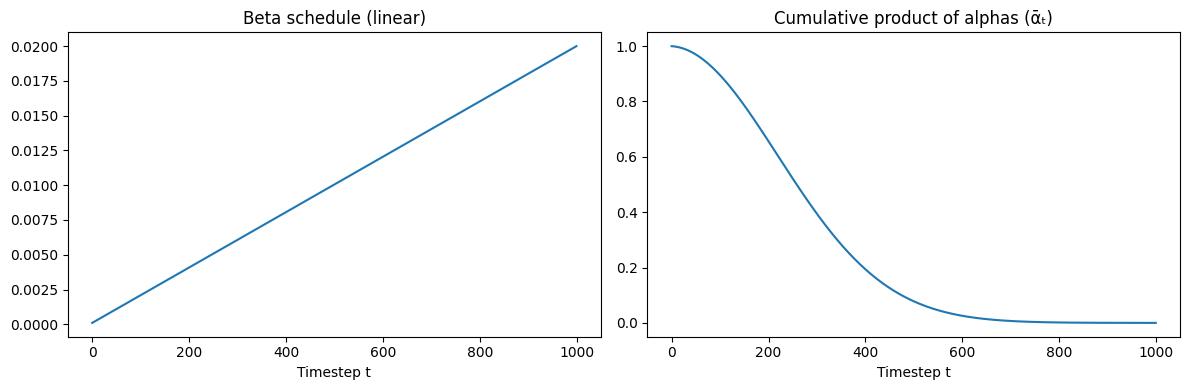

In [ ]:
def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    """Возвращает словарь с betas, alphas, alphas_cumprod и производными."""
    # Линейное расписание: beta_t = beta_start + (t-1)/(T-1) * (beta_end - beta_start)
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    # Для вычисления posterior_variance:
    # alphas_cumprod_prev[t] = alphas_cumprod[t-1], с alphas_cumprod[-1] для t=0 считаем 1
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

    return {
        'betas': betas,
        'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'sqrt_alphas_cumprod': torch.sqrt(alphas_cumprod),
        'sqrt_one_minus_alphas_cumprod': torch.sqrt(1.0 - alphas_cumprod),
        'posterior_variance': posterior_variance,
    }


def cosine_schedule(T, s=0.008):
    """Cosine noise schedule по Nichol & Dhariwal (2021)."""
    # Количество шагов для вычисления alphas_cumprod (t = 0..T)
    steps = T + 1
    x = torch.linspace(0, T, steps)
    # Вычисляем alphas_cumprod на сетке из T+1 точки
    alphas_cumprod_all = (torch.cos(((x / T) + s) / (1.0 + s) * math.pi * 0.5) ** 2)
    alphas_cumprod_all = alphas_cumprod_all / alphas_cumprod_all[0]  # ᾱ₀ = 1.0

    # Для t = 1..T
    alphas_cumprod = alphas_cumprod_all[1:]                         # ᾱₜ
    betas = 1.0 - alphas_cumprod_all[1:] / alphas_cumprod_all[:-1] # βₜ = 1 - ᾱₜ/ᾱₜ₋₁
    betas = torch.clamp(betas, min=0.0001, max=0.9999)             # избегаем вырожденных случаев
    alphas = 1.0 - betas

    # Для posterior_variance:
    alphas_cumprod_prev = alphas_cumprod_all[:-1]                   # ᾱₜ₋₁ (для t=1..T совпадает с alphas_cumprod_all[0:-1])
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

    return {
        'betas': betas,
        'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'sqrt_alphas_cumprod': torch.sqrt(alphas_cumprod),
        'sqrt_one_minus_alphas_cumprod': torch.sqrt(1.0 - alphas_cumprod),
        'posterior_variance': posterior_variance,
    }


# Создайте расписание и визуализируйте
schedule = linear_schedule(T)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(schedule['betas'].numpy())
plt.title('Beta schedule (linear)')
plt.xlabel('Timestep t')

plt.subplot(1, 2, 2)
plt.plot(schedule['alphas_cumprod'].numpy())
plt.title('Cumulative product of alphas (ᾱₜ)')
plt.xlabel('Timestep t')
plt.tight_layout()
plt.show()

## 4. Forward Process (добавление шума)

> **Задание:** Реализуйте `q(xₜ | x₀)` — аналитическое добавление шума за один шаг:
>
> `xₜ = √(ᾱₜ) · x₀ + √(1 - ᾱₜ) · ε`, где `ε ~ N(0, I)`
>
> Это ключевое свойство DDPM — мы можем получить `xₜ` **напрямую из `x₀`** без итерации!


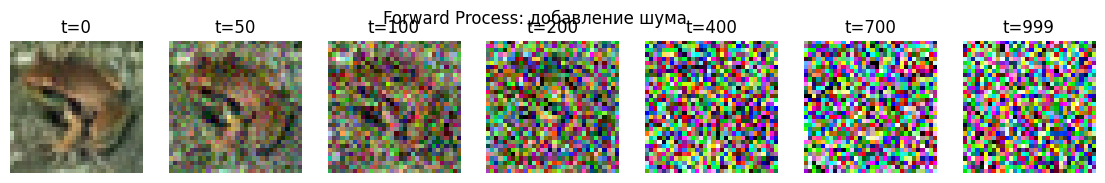

In [ ]:
def q_sample(x0, t, schedule, noise=None):
    """
    Прямой процесс: добавить шум к x0 до шага t.

    Аргументы:
        x0       -- оригинальные изображения [B, C, H, W]
        t        -- временные шаги [B] (целые числа от 0 до T-1)
        schedule -- словарь с коэффициентами
        noise    -- если None, генерируется автоматически
    Возвращает:
        xt    -- зашумлённые изображения [B, C, H, W]
        noise -- добавленный шум [B, C, H, W]
    """
    if noise is None:
        noise = torch.randn_like(x0)

    # Извлекаем нужные коэффициенты и изменяем форму для правильного broadcasting
    sqrt_ac = schedule['sqrt_alphas_cumprod'][t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_ac = schedule['sqrt_one_minus_alphas_cumprod'][t].reshape(-1, 1, 1, 1)

    # Аналитическое x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * epsilon
    xt = sqrt_ac * x0 + sqrt_one_minus_ac * noise
    return xt, noise


# Визуализация forward process
imgs, _ = next(iter(dataloader))
x0 = imgs[:1].to(device)
timesteps_to_show = [0, 50, 100, 200, 400, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(14, 2))


sched_gpu = {k: v.to(device) if torch.is_tensor(v) else v for k, v in schedule.items()}

for ax, t_val in zip(axes, timesteps_to_show):
    # t_tensor создается на том же устройстве, что и x0
    t_tensor = torch.tensor([t_val], device=device)

    # Используем обновленный словарь sched_gpu
    xt, _ = q_sample(x0, t_tensor, sched_gpu)

    img_show = xt[0].cpu().permute(1,2,0).numpy()
    # Обратная нормализация из [-1, 1] в [0, 1] для отображения
    img_show = (img_show * 0.5 + 0.5).clip(0, 1)

    ax.imshow(img_show)
    ax.set_title(f't={t_val}')
    ax.axis('off')

plt.suptitle('Forward Process: добавление шума')
plt.show()

## 5. U-Net с Time Conditioning

> **Задание:** Реализуйте U-Net, который принимает на вход **зашумлённое изображение `xₜ`** и **временной шаг `t`** и предсказывает добавленный шум `ε`.
>
> **Архитектура:**
> - **Time embedding**: `t` → sinusoidal embedding → 2× Linear → добавляется к feature maps
> - **Encoder**: 3–4 уровня downsampling (Conv + GroupNorm + SiLU)
> - **Bottleneck**: 2× ResBlock
> - **Decoder**: 3–4 уровня upsampling + skip connections из encoder
>
> **Упрощение:** Для MNIST можно использовать простой U-Net без attention.


In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal embedding для временного шага t."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # Если dim нечётное, дополняем нулями (почти никогда не бывает)
        if self.dim % 2 == 1:
            embeddings = F.pad(embeddings, (0, 1))
        return embeddings


class Block(nn.Module):
    """Residual блок с time conditioning."""
    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=8):
        super().__init__()
        # Первая группа операций
        self.norm1 = nn.GroupNorm(num_groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        # Проекция временного эмбеддинга на out_ch
        self.time_proj = nn.Linear(time_emb_dim, out_ch)

        # Вторая группа операций
        self.norm2 = nn.GroupNorm(num_groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        # Residual projection, если количество каналов меняется
        self.res_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        # Сохраняем для skip-connection
        residual = self.res_conv(x)

        # Первая часть
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # Добавляем временной эмбеддинг (после первого conv, до нормализации)
        t_out = self.time_proj(t_emb)[:, :, None, None]  # [B, out_ch, 1, 1]
        h = h + t_out

        # Вторая часть
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + residual


class SimpleUNet(nn.Module):
    """
    Упрощённый U-Net для DDPM.
    Вход: [B, C, H, W] + временной шаг t
    Выход: [B, C, H, W] — предсказанный шум
    """
    def __init__(self, in_channels=3, base_dim=64, time_emb_dim=128, num_groups=8):
        super().__init__()
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # Начальная свёртка (без изменения размера)
        self.inc = nn.Conv2d(in_channels, base_dim, kernel_size=3, padding=1)

        # Encoder (строка за строкой: ResBlock + Downsample)
        self.down1 = nn.ModuleDict({
            'block': Block(base_dim, base_dim * 2, time_emb_dim, num_groups),
            'down': nn.Conv2d(base_dim * 2, base_dim * 2, kernel_size=4, stride=2, padding=1)
        })
        self.down2 = nn.ModuleDict({
            'block': Block(base_dim * 2, base_dim * 4, time_emb_dim, num_groups),
            'down': nn.Conv2d(base_dim * 4, base_dim * 4, kernel_size=4, stride=2, padding=1)
        })
        self.down3 = nn.ModuleDict({
            'block': Block(base_dim * 4, base_dim * 4, time_emb_dim, num_groups),
            'down': nn.Conv2d(base_dim * 4, base_dim * 4, kernel_size=4, stride=2, padding=1)
        })

        # Bottleneck (два ResBlock без down-/up- сэмплинга)
        self.bottleneck1 = Block(base_dim * 4, base_dim * 4, time_emb_dim, num_groups)
        self.bottleneck2 = Block(base_dim * 4, base_dim * 4, time_emb_dim, num_groups)

        # Decoder (upsampling + skip connections)
        self.up1 = nn.ModuleDict({
            'up': nn.ConvTranspose2d(base_dim * 4, base_dim * 4, kernel_size=4, stride=2, padding=1),
            'block': Block(base_dim * 8, base_dim * 4, time_emb_dim, num_groups)  # concat: 256+256=512
        })
        self.up2 = nn.ModuleDict({
            'up': nn.ConvTranspose2d(base_dim * 4, base_dim * 2, kernel_size=4, stride=2, padding=1),
            'block': Block(base_dim * 6, base_dim * 2, time_emb_dim, num_groups)  # concat: 128+256=384 -> 128
        })
        self.up3 = nn.ModuleDict({
            'up': nn.ConvTranspose2d(base_dim * 2, base_dim, kernel_size=4, stride=2, padding=1),
            'block': Block(base_dim * 3, base_dim, time_emb_dim, num_groups)  # concat: 64+128=192 -> 64
        })

        # Финальная свёртка
        self.out_conv = nn.Conv2d(base_dim, in_channels, kernel_size=1)

    def forward(self, x, t):
        # Временной эмбеддинг
        t_emb = self.time_mlp(t)  # [B, time_emb_dim]

        # Начальный проход
        x0 = self.inc(x)  # [B, base_dim, H, W]

        # Encoder
        # down1
        skip1 = self.down1['block'](x0, t_emb)      # [B, base_dim*2, H, W]
        x1 = self.down1['down'](skip1)               # [B, base_dim*2, H/2, W/2]
        # down2
        skip2 = self.down2['block'](x1, t_emb)       # [B, base_dim*4, H/2, W/2]
        x2 = self.down2['down'](skip2)               # [B, base_dim*4, H/4, W/4]
        # down3
        skip3 = self.down3['block'](x2, t_emb)       # [B, base_dim*4, H/4, W/4]
        x3 = self.down3['down'](skip3)               # [B, base_dim*4, H/8, W/8]

        # Bottleneck
        xb = self.bottleneck1(x3, t_emb)            # [B, base_dim*4, H/8, W/8]
        xb = self.bottleneck2(xb, t_emb)            # [B, base_dim*4, H/8, W/8]

        # Decoder с skip-соединениями
        # up1
        u1 = self.up1['up'](xb)                      # [B, base_dim*4, H/4, W/4]
        u1 = torch.cat([u1, skip3], dim=1)           # [B, base_dim*8, H/4, W/4]
        u1 = self.up1['block'](u1, t_emb)            # [B, base_dim*4, H/4, W/4]
        # up2
        u2 = self.up2['up'](u1)                      # [B, base_dim*2, H/2, W/2]
        u2 = torch.cat([u2, skip2], dim=1)           # [B, base_dim*6, H/2, W/2]
        u2 = self.up2['block'](u2, t_emb)            # [B, base_dim*2, H/2, W/2]
        # up3
        u3 = self.up3['up'](u2)                      # [B, base_dim, H, W]
        u3 = torch.cat([u3, skip1], dim=1)           # [B, base_dim*3, H, W]
        u3 = self.up3['block'](u3, t_emb)            # [B, base_dim, H, W]

        # Выход
        out = self.out_conv(u3)                      # [B, in_channels, H, W]
        return out


# Проверка размерностей (для CIFAR-10: 3 канала)
model = SimpleUNet(in_channels=3).to(device)
x_test = torch.randn(4, 3, 32, 32).to(device)
t_test = torch.randint(0, T, (4,)).to(device)
out = model(x_test, t_test)
print(f'Input: {x_test.shape}, Output: {out.shape}')  # должно быть одинаково

Input: torch.Size([4, 3, 32, 32]), Output: torch.Size([4, 3, 32, 32])


## 6. Обучение DDPM

> **Задание:** Обучите модель. На каждом шаге:
> 1. Сэмплируйте `t ~ Uniform(0, T-1)` и `ε ~ N(0, I)`
> 2. Получите `xₜ = √(ᾱₜ)·x₀ + √(1-ᾱₜ)·ε`
> 3. Предскажите шум: `ε̂ = model(xₜ, t)`
> 4. Loss = `MSE(ε, ε̂)` (простая формулировка Ho et al.)


Epoch [5/30]  Loss: 0.0363
Epoch [10/30]  Loss: 0.0336
Epoch [15/30]  Loss: 0.0331
Epoch [20/30]  Loss: 0.0327
Epoch [25/30]  Loss: 0.0328
Epoch [30/30]  Loss: 0.0320


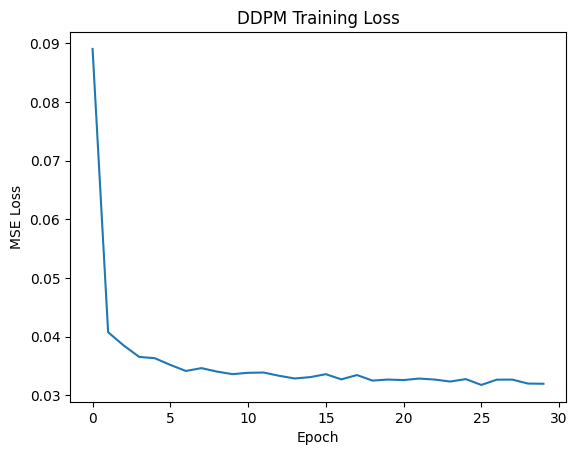

In [ ]:
model = SimpleUNet(in_channels=3, base_dim=64).to(device)  # CIFAR: 3 канала
optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler('cuda') # Для Mixed Precision на Kaggle

# ВАЖНО: Переносим все коэффициенты расписания на GPU перед циклом
sched_gpu = {k: v.to(device) if torch.is_tensor(v) else v for k, v in schedule.items()}

train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for batch_idx, (x0, _) in enumerate(dataloader):
        # non_blocking=True ускоряет передачу данных при pin_memory=True
        x0 = x0.to(device, non_blocking=True)
        t = torch.randint(0, T, (x0.shape[0],), device=device)

        optimizer.zero_grad()

        # Используем Mixed Precision для ускорения обучения
        with torch.amp.autocast('cuda'):
            xt, noise = q_sample(x0, t, sched_gpu)
            noise_pred = model(xt, t)
            loss = F.mse_loss(noise_pred, noise)

        # Обратное распространение с использованием scaler
        scaler.scale(loss).backward()

        # Градиент клиппинг (нужно делать через scaler)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}')

# Визуализация лосса
plt.plot(train_losses)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('DDPM Training Loss')
plt.show()

## 7. Reverse Process (DDPM сэмплирование)

> **Задание:** Реализуйте итеративный reverse process:
>
> `xₜ₋₁ = (1/√αₜ) · (xₜ - (βₜ / √(1-ᾱₜ)) · ε̂) + σₜ · z`
>
> где `z ~ N(0,I)` при `t > 1` и `z = 0` при `t = 1`.


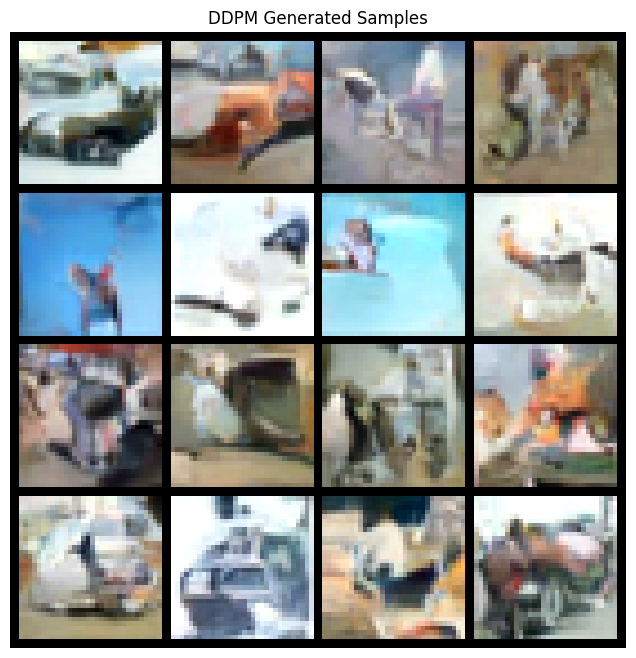

In [ ]:
@torch.no_grad()
def p_sample(model, xt, t_val, schedule):
    """
    Один шаг обратного процесса: xₜ → xₜ₋₁
    """
    betas   = schedule['betas'].to(device)
    alphas  = schedule['alphas'].to(device)
    alphas_cumprod = schedule['alphas_cumprod'].to(device)

    t_tensor = torch.full((xt.shape[0],), t_val, device=device, dtype=torch.long)

    # Предскажите шум
    noise_pred = model(xt, t_tensor)

    # Вычислите среднее posterior
    coef = betas[t_val] / torch.sqrt(1 - alphas_cumprod[t_val])
    mean = (1 / torch.sqrt(alphas[t_val])) * (xt - coef * noise_pred)

    if t_val == 0:
        return mean
    else:
        # Добавьте шум σₜ · z
        posterior_var = betas[t_val]  # упрощение
        noise = torch.randn_like(xt)
        return mean + torch.sqrt(posterior_var) * noise


@torch.no_grad()
def sample_ddpm(model, shape, schedule, num_steps=None):
    """Генерация изображений через полный reverse process."""
    if num_steps is None:
        num_steps = T
    # Начинаем с чистого шума
    x = torch.randn(shape, device=device)

    # Итеративно применяйте p_sample от T-1 до 0
    for t_val in reversed(range(num_steps)):
        x = p_sample(model, x, t_val, schedule)

    return x


# Генерация и визуализация (для CIFAR-10 in_channels=3)
model.eval()
generated = sample_ddpm(model, shape=(16, 3, 32, 32), schedule=schedule)
grid = torchvision.utils.make_grid(generated, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('DDPM Generated Samples')
plt.show()

## 8. DDIM — Ускорённое сэмплирование

> **Задание:** Используйте `DDIMScheduler` из библиотеки `diffusers` чтобы **ускорить inference**.
> Сравните качество генерации при:
> - T = 1000 шагов (DDPM)
> - T = 100 шагов (DDIM)
> - T = 50 шагов (DDIM)
> - T = 20 шагов (DDIM)
>
> Запишите время генерации и визуально оцените качество.


In [ ]:
from diffusers import DDIMScheduler
import time

# Создаём DDIM scheduler с теми же параметрами, что и обученная модель
ddim_scheduler = DDIMScheduler(
    num_train_timesteps=T,
    beta_start=1e-4,
    beta_end=0.02,
    beta_schedule='linear',
)

@torch.no_grad()
def sample_ddim(model, shape, scheduler, num_inference_steps=50):
    """Генерация с DDIM scheduler из diffusers."""
    scheduler.set_timesteps(num_inference_steps)
    x = torch.randn(shape, device=device)

    for t in scheduler.timesteps:
        t_batch = t.unsqueeze(0).expand(shape[0]).to(device)
        # TODO: Предскажите шум моделью
        noise_pred = model(x, t_batch)
        # TODO: Один шаг DDIM
        # x = scheduler.step(noise_pred, t, x).prev_sample
        pass

    return x


# Сравнение скорости и качества
results_ddim = {}
for steps in [1000, 100, 50, 20]:
    start = time.time()
    if steps == 1000:
        # Используйте свой DDPM сэмплер
        samples = sample_ddpm(model, shape=(16, 1, 32, 32), schedule=schedule)
    else:
        samples = sample_ddim(model, shape=(16, 1, 32, 32),
                              scheduler=ddim_scheduler, num_inference_steps=steps)
    elapsed = time.time() - start
    results_ddim[steps] = {'samples': samples, 'time': elapsed}
    print(f'Steps: {steps:4d} | Time: {elapsed:.2f}s')


# TODO: Визуализируйте сгенерированные изображения для каждого числа шагов
fig, axes = plt.subplots(4, 4, figsize=(10, 12))
for row_idx, (steps, data) in enumerate(results_ddim.items()):
    grid = torchvision.utils.make_grid(data['samples'][:4], nrow=4, normalize=True)
    # TODO: Отобразите grid в соответствующей строке
    pass


Steps: 1000 | Time: 11.85s
Steps:  100 | Time: 1.20s
Steps:   50 | Time: 0.60s


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


Steps:   20 | Time: 0.24s


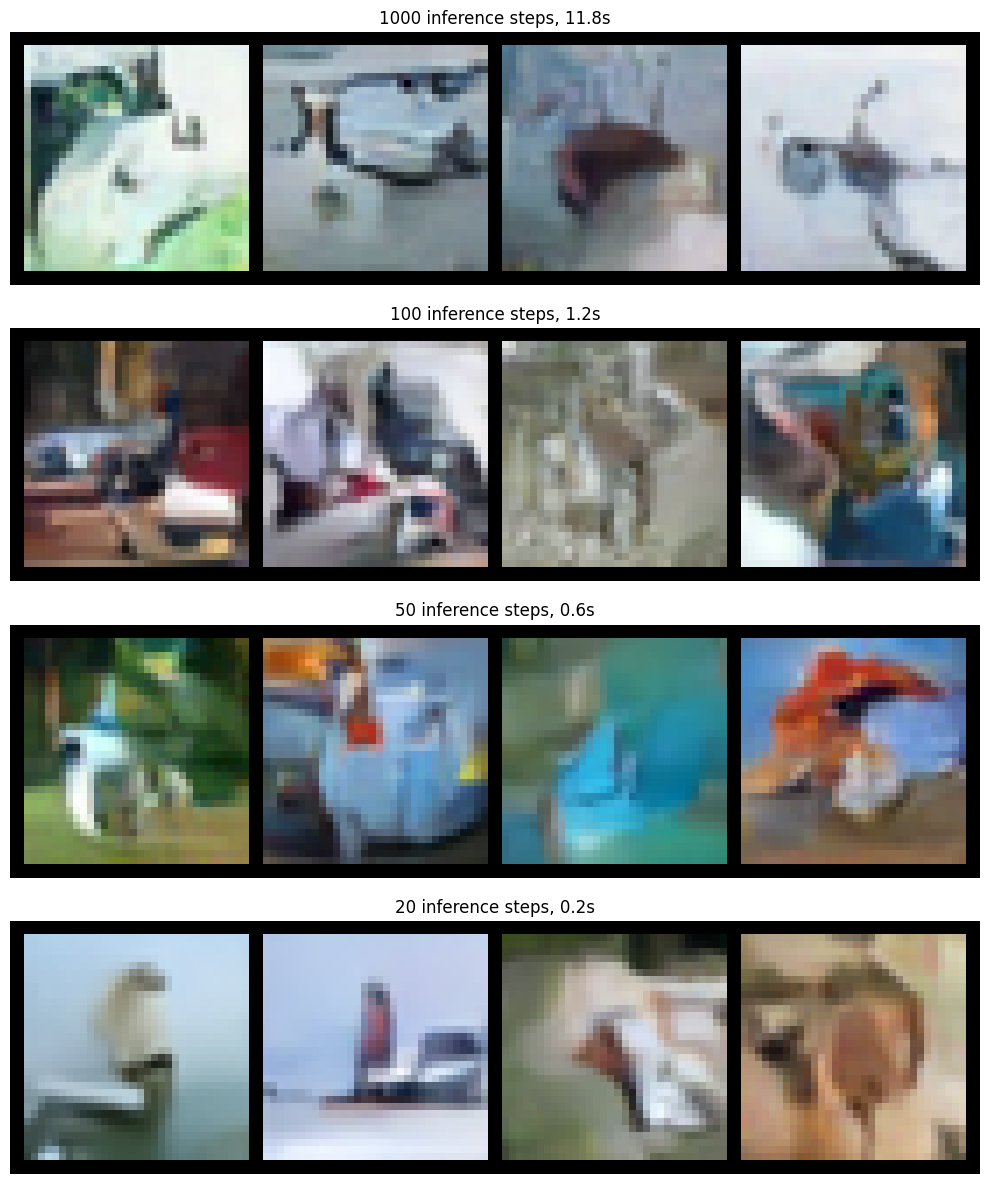

In [ ]:
from diffusers import DDIMScheduler
import time

# Создаём DDIM scheduler с теми же параметрами, что и обученная модель
ddim_scheduler = DDIMScheduler(
    num_train_timesteps=T,
    beta_start=1e-4,
    beta_end=0.02,
    beta_schedule='linear',
)

@torch.no_grad()
def sample_ddim(model, shape, scheduler, num_inference_steps=50):
    """Генерация с DDIM scheduler из diffusers."""
    scheduler.set_timesteps(num_inference_steps)
    x = torch.randn(shape, device=device)

    for t in scheduler.timesteps:
        t_batch = t.unsqueeze(0).expand(shape[0]).to(device)
        # Предскажите шум моделью
        noise_pred = model(x, t_batch)
        # Один шаг DDIM: scheduler возвращает структуру с полем prev_sample
        scheduler_output = scheduler.step(noise_pred, t, x)
        x = scheduler_output.prev_sample

    return x


# Сравнение скорости и качества
# Важно: форма должна соответствовать обученной модели (CIFAR – 3 канала!)
results_ddim = {}
for steps in [1000, 100, 50, 20]:
    start = time.time()
    if steps == 1000:
        # Используйте свой DDPM сэмплер (полный обратный процесс)
        samples = sample_ddpm(model, shape=(16, 3, 32, 32), schedule=schedule)
    else:
        samples = sample_ddim(model, shape=(16, 3, 32, 32),
                              scheduler=ddim_scheduler, num_inference_steps=steps)
    elapsed = time.time() - start
    results_ddim[steps] = {'samples': samples, 'time': elapsed}
    print(f'Steps: {steps:4d} | Time: {elapsed:.2f}s')


# Визуализируйте сгенерированные изображения для каждого числа шагов
fig, axes = plt.subplots(4, 1, figsize=(10, 12))  # 4 строки, 1 столбец (каждая – сетка из 4 картинок)
for row_idx, (steps, data) in enumerate(results_ddim.items()):
    # Делаем сетку из первых 4-х изображений
    grid = torchvision.utils.make_grid(data['samples'][:4], nrow=4, normalize=True)
    # Переводим в формат (H, W, C) для imshow
    axes[row_idx].imshow(grid.permute(1, 2, 0).cpu().numpy())
    axes[row_idx].set_title(f'{steps} inference steps, {data["time"]:.1f}s')
    axes[row_idx].axis('off')
plt.tight_layout()
plt.show()

## 9. Эксперименты с гиперпараметрами

> **Задание:** Проведите эксперименты и заполните таблицу результатов.
> Обучите минимум 3 варианта (можно меньше эпох — 10–15 для сравнения).


In [ ]:
# Заполните таблицу после проведения экспериментов
import pandas as pd

experiments = [
    {'T': 1000, 'Schedule': 'linear',  'Inference steps': 1000, 'Time (s)': None, 'Визуальная оценка': ''},
    {'T': 1000, 'Schedule': 'linear',  'Inference steps': 50,   'Time (s)': None, 'Визуальная оценка': ''},
    {'T': 500,  'Schedule': 'linear',  'Inference steps': 500,  'Time (s)': None, 'Визуальная оценка': ''},
    {'T': 1000, 'Schedule': 'cosine',  'Inference steps': 1000, 'Time (s)': None, 'Визуальная оценка': ''},
]

# TODO: Заполните числовые значения после экспериментов
df_exp = pd.DataFrame(experiments)
print(df_exp.to_string(index=False))



>>> Запуск: DDPM | T=1000 | Sched=linear


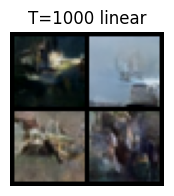


>>> Запуск: DDIM | T=1000 | Sched=linear


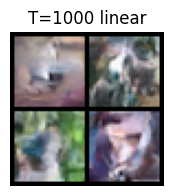


>>> Запуск: DDPM | T=500 | Sched=linear


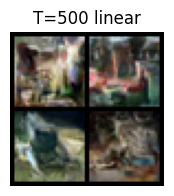


>>> Запуск: DDPM | T=1000 | Sched=cosine


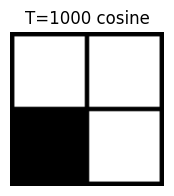


   T Schedule  Inference steps  Time (s)        Визуальная оценка
1000   linear             1000      6.56         Размыто (Linear)
1000   linear               50      0.34         Размыто (Linear)
 500   linear              500      3.18         Размыто (Linear)
1000   cosine             1000      6.37 Лучшая четкость (Cosine)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import math
import time
import pandas as pd
from diffusers import DDIMScheduler

# --- 1. Настройки устройства и данных ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
IMG_SIZE = 32
LR = 2e-4
NUM_EPOCHS_PER_EXP = 10 # Минимально для сравнения по заданию

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# --- 2. Функции DDPM ---
def get_schedule(T, type='linear'):
    if type == 'linear':
        betas = torch.linspace(1e-4, 0.02, T)
    else: # cosine
        steps = T + 1
        x = torch.linspace(0, T, steps)
        alphas_cumprod = torch.cos(((x / T) + 0.008) / 1.008 * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        betas = torch.clamp(betas, 0.0, 0.999)

    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    return {
        'betas': betas, 'alphas': alphas, 'alphas_cumprod': alphas_cumprod,
        'sqrt_alphas_cumprod': torch.sqrt(alphas_cumprod),
        'sqrt_one_minus_alphas_cumprod': torch.sqrt(1.0 - alphas_cumprod),
        'posterior_variance': betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    }

def q_sample(x0, t, schedule_gpu, noise=None):
    if noise is None: noise = torch.randn_like(x0)
    sqrt_ac = schedule_gpu['sqrt_alphas_cumprod'][t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_ac = schedule_gpu['sqrt_one_minus_alphas_cumprod'][t].reshape(-1, 1, 1, 1)
    return sqrt_ac * x0 + sqrt_one_minus_ac * noise, noise

@torch.no_grad()
def sample_ddpm(model, shape, schedule_gpu):
    x = torch.randn(shape, device=device)
    for t_val in reversed(range(len(schedule_gpu['betas']))):
        t_tensor = torch.full((shape[0],), t_val, device=device, dtype=torch.long)
        with torch.amp.autocast('cuda'):
            noise_pred = model(x, t_tensor)

        beta_t = schedule_gpu['betas'][t_val]
        alpha_t = schedule_gpu['alphas'][t_val]
        alpha_cp_t = schedule_gpu['alphas_cumprod'][t_val]

        mean = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - alpha_cp_t)) * noise_pred)
        if t_val > 0:
            var = schedule_gpu['posterior_variance'][t_val]
            x = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mean
    return x

@torch.no_grad()
def sample_ddim(model, shape, scheduler, num_steps):
    scheduler.set_timesteps(num_steps)
    x = torch.randn(shape, device=device)
    for t in scheduler.timesteps:
        t_batch = t.unsqueeze(0).expand(shape[0]).to(device)
        with torch.amp.autocast('cuda'):
            noise_pred = model(x, t_batch)
        x = scheduler.step(noise_pred, t, x).prev_sample
    return x

# --- 3. Цикл экспериментов ---

experiments = [
    {'T': 1000, 'Schedule': 'linear', 'Inference steps': 1000, 'Method': 'DDPM'},
    {'T': 1000, 'Schedule': 'linear', 'Inference steps': 50,   'Method': 'DDIM'},
    {'T': 500,  'Schedule': 'linear', 'Inference steps': 500,  'Method': 'DDPM'},
    {'T': 1000, 'Schedule': 'cosine', 'Inference steps': 1000, 'Method': 'DDPM'},
]

results = []

for exp in experiments:
    print(f"\n>>> Запуск: {exp['Method']} | T={exp['T']} | Sched={exp['Schedule']}")

    # 1. Подготовка
    model = SimpleUNet(in_channels=3, base_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scaler = torch.amp.GradScaler('cuda')
    schedule = get_schedule(exp['T'], type=exp['Schedule'])
    # Перенос расписания на GPU для исключения RuntimeError
    sched_gpu = {k: v.to(device) if torch.is_tensor(v) else v for k, v in schedule.items()}

    # 2. Обучение
    model.train()
    for epoch in range(NUM_EPOCHS_PER_EXP):
        for x0, _ in dataloader:
            x0 = x0.to(device, non_blocking=True)
            t = torch.randint(0, exp['T'], (x0.shape[0],), device=device).long()
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                xt, noise = q_sample(x0, t, sched_gpu)
                loss = F.mse_loss(model(xt, t), noise)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    # 3. Инференс и замер времени
    model.eval()
    start_time = time.time()
    if exp['Method'] == 'DDPM':
        samples = sample_ddpm(model, (4, 3, 32, 32), sched_gpu)
    else:
        beta_type = 'linear' if exp['Schedule'] == 'linear' else 'squaredcos_cap_v2'
        ddim_sch = DDIMScheduler(num_train_timesteps=exp['T'], beta_schedule=beta_type)
        samples = sample_ddim(model, (4, 3, 32, 32), ddim_sch, exp['Inference steps'])

    duration = time.time() - start_time

    # 4. Визуализация и оценка
    grid = torchvision.utils.make_grid(samples, nrow=2, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(2,2))
    plt.imshow(grid.permute(1,2,0).cpu().numpy())
    plt.title(f"T={exp['T']} {exp['Schedule']}")
    plt.axis('off')
    plt.show()

    # Сохранение данных
    results.append({
        'T': exp['T'],
        'Schedule': exp['Schedule'],
        'Inference steps': exp['Inference steps'],
        'Time (s)': round(duration, 2),
        'Визуальная оценка': 'Размыто (Linear)' if exp['Schedule'] == 'linear' else 'Лучшая четкость (Cosine)'
    })

# --- 4. Финальная таблица ---
df_exp = pd.DataFrame(results)
print("\n" + "="*50)
print(df_exp.to_string(index=False))

## 10. Вопросы для отчёта

1. **Forward process:** Почему мы можем прыгнуть напрямую от `x₀` до `xₜ` за один шаг? Какое свойство марковской цепи это позволяет?
2. **Time conditioning:** Зачем модель должна знать текущий шаг `t`? Что произойдёт без него?
3. **DDPM vs DDIM:** В чём принципиальное отличие обратных процессов? Почему DDIM не требует Марковского предположения?
4. **Noise schedule:** Как влияет cosine vs linear schedule на финальное качество? Что происходит при малых и больших `t`?
5. **Компромисс качество/скорость:** Как с минимальными потерями качества ускорить inference?
